# Heart disease prediction notebook for Kaggle

In [55]:
import pandas as pd
import numpy as np
from pathlib import Path

CSV_PATH_TRAIN = Path("data/train.csv")
CSV_PATH_TEST = Path("data/test.csv")
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [56]:
df = pd.read_csv(CSV_PATH_TRAIN, sep=",")
y = df["Heart Disease"]

df_copy = df.copy()
df.head()

cols_num = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
cols_cat = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 
            'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

This classification dataset is used to predict the presence of cardiovascular disease based on clinical and biological parameters.

| Column | Technical Name | Description & Values |
| :--- | :--- | :--- |
| **Age** | Age | Patient's age (in years). |
| **Sex** | Sex | 1 = Male; 0 = Female. |
| **Chest pain type** | cp | 1: Typical angina, 2: Atypical angina, 3: Non-anginal pain, 4: Asymptomatic. |
| **BP** | trestbps | Resting blood pressure (in mm Hg on admission to the hospital). |
| **Cholesterol** | chol | Serum cholesterol in mg/dl. |
| **FBS over 120** | fbs | Fasting blood sugar > 120 mg/dl (1 = True; 0 = False). |
| **EKG results** | restecg | 0: Normal, 1: ST-T wave abnormality, 2: Left ventricular hypertrophy. |
| **Max HR** | thalach | Maximum heart rate achieved during stress test. |
| **Exercise angina** | exang | Exercise-induced angina (1 = Yes; 0 = No). |
| **ST depression** | oldpeak | ST depression induced by exercise relative to rest. |
| **Slope of ST** | slope | Slope of the peak exercise ST segment (1: Upsloping, 2: Flat, 3: Downsloping). |
| **Number of vessels fluro** | ca | Number of major vessels (0-3) colored by fluoroscopy. |
| **Thallium** | thal | 3: Normal, 6: Fixed defect, 7: Reversible defect. |
| **Heart Disease** | **Target** | Presence of heart disease (1 = Presence; 0 = Absence). |

In [57]:
scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded_cat = encoder.fit_transform(df[cols_cat])
cat_names = encoder.get_feature_names_out(cols_cat)
df_res = pd.DataFrame(encoded_cat, columns=cat_names)

In [58]:
from sklearn import set_config

df_train = pd.read_csv(CSV_PATH_TRAIN, sep=",")
df_test = pd.read_csv(CSV_PATH_TEST, sep=",")


transformer_num = StandardScaler()
transformer_cat = OneHotEncoder(handle_unknown='ignore', sparse_output=False) 

set_config(transform_output="pandas")

preprocessor = ColumnTransformer(
    transformers=[
        ('num', transformer_num, cols_num),
        ('cat', transformer_cat, cols_cat)
    ],
    remainder='drop'
)
X_train_clean = preprocessor.fit_transform(df_train)
X_test_clean = preprocessor.transform(df_test)

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X_train_clean, y, test_size=0.2, random_state=42)

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model_rf = RandomForestClassifier(n_estimators=100, random_state=4, n_jobs=-1)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

score = accuracy_score(y_pred, y_test)
print(f"accuracy score of rf model is {score * 100:.2f}%")

accuracy score of rf model is 87.88%


In [61]:
y_pred_kaggle = model_rf.predict(X_test_clean)
y_pred_kaggle = np.where(y_pred_kaggle == "Presence", 1, 0)
y_pred_kaggle_df = pd.DataFrame({
    "id" : df_test.id,
    "Heart Disease" : y_pred_kaggle
})
y_pred_kaggle_df.to_csv("data/kaggle_sub_rf_100estimators.csv", index=False)
y_pred_kaggle_df.head()


,id,Heart Disease
0,630000,1
1,630001,0
2,630002,1
3,630003,0
4,630004,0


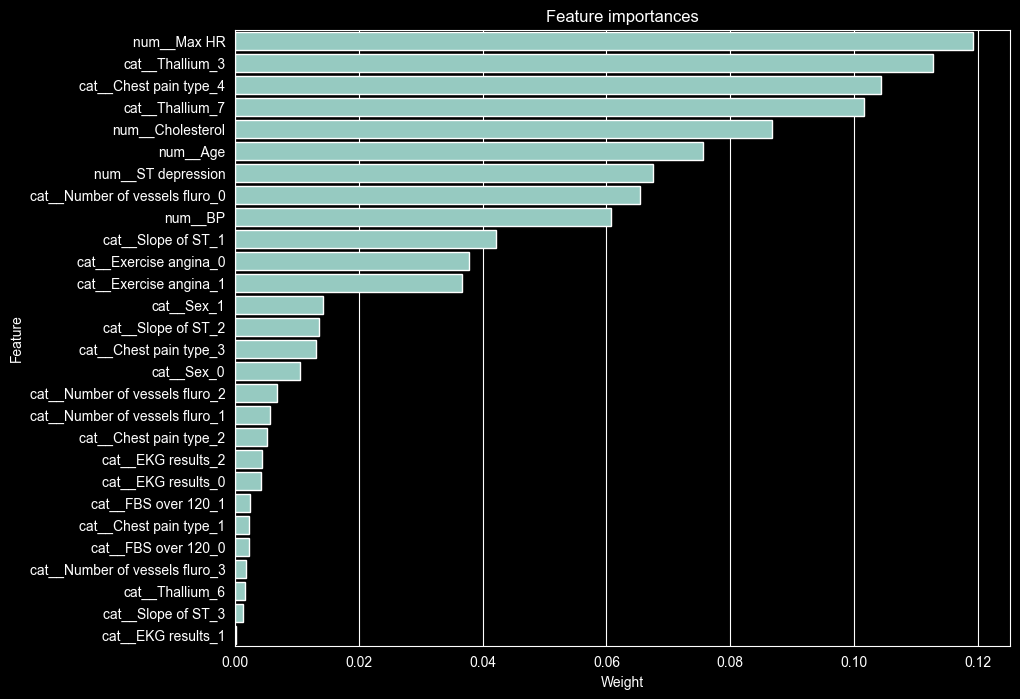

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = preprocessor.get_feature_names_out()
weights = model_rf.feature_importances_

df_importances = pd.DataFrame({
    "Variable": feature_names,
    "Importance": weights}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x = "Importance", y = "Variable", data=df_importances)
plt.title("Feature importances")
plt.xlabel("Weight")
plt.ylabel("Feature")
plt.show()

In [70]:
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(model_rf, threshold=0.02, prefit=True)

X_train_purged = selector.transform(X_train_clean)
X_test_kaggle_purged = selector.transform(X_test_clean)

selected_mask = selector.get_support()
selected_columns = X_train_clean.columns[selected_mask]

X_train_purged_df = pd.DataFrame(X_train_purged, columns=selected_columns)
X_test_kaggle_purged_df = pd.DataFrame(X_test_kaggle_purged, columns=selected_columns)
X_test_kaggle_purged_df["id"] = df_test.id

X_train_purged_df["Heart Disease"] = y

df_shuffled = X_train_purged_df.sample(frac=1, random_state=42).reset_index(drop=True)

df_shuffled.to_csv("data/X_train_purged_df.csv", index=False)
X_test_kaggle_purged_df.to_csv("data/X_test_kaggle_purged_df.csv", index=False)


print(f"Kept columns : {list(selected_columns)}")

columns_before = X_train_clean.shape[1]
columns_after = X_train_purged.shape[1]

print(f"Hyperpsace dimension BEFORE: {columns_before} features")
print(f"Hyperpsace dimension AFTER: {columns_after} features (Pure signal)")

C:\Users\lucas\Documents\Kaggle\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\lucas\Documents\Kaggle\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Kept columns : ['num__Age', 'num__BP', 'num__Cholesterol', 'num__Max HR', 'num__ST depression', 'cat__Chest pain type_4', 'cat__Exercise angina_0', 'cat__Exercise angina_1', 'cat__Slope of ST_1', 'cat__Number of vessels fluro_0', 'cat__Thallium_3', 'cat__Thallium_7']
Hyperpsace dimension BEFORE: 28 features
Hyperpsace dimension AFTER: 12 features (Pure signal)
